## Federated Learning + AI Data Readiness Inspection: Launching the Server


<img src="https://github.com/APPFL/APPFL/blob/main/docs/_static/logo/logo_small.png?raw=true" width="40%" alt="APPFL Logo">


In this tutorial, we will leverage the Advanced Privacy-Preserving Federated Learning ([APPFL](https://github.com/APPFL/APPFL)) framework to launch a federated learning server that orchestrates a federated learning experiment between two distributed clients, whose client-launching code is available in your Jupyter workspace as **Client1 (APPFL_Client1_MNIST_AIDRIN.ipynb)** and **Client2 (APPFL_Client2_MNIST_AIDRIN.ipynb)**.

On top of plain federated training, this example adds an **AI data readiness (DR) inspection** step: before any training happens, every client evaluates the quality of its own local dataset, optionally repairs it using a **CADRE module**, and sends a privacy-preserving readiness report back to the server. The server merges all client reports into a single HTML dashboard that you will render at the end of this notebook.



### 1. Introduction to Federated Learning

As shown in the figure below, federated learning can be understood as a distributed version of traditional machine learning by iterating the following two steps after a model initialization step

(1) Each client trains an ML model using its local dataset and submits the updated model to the server.

(2) The server aggregates these local models to update the global model and then sends it back to the clients for further local training.

As only model parameters are exchanged, federated learning offers a promising solution to utilize data from multiple data owners without direct data sharing, and it can usually help with training more robust, generalized, and powerful model by leveraging more training data.


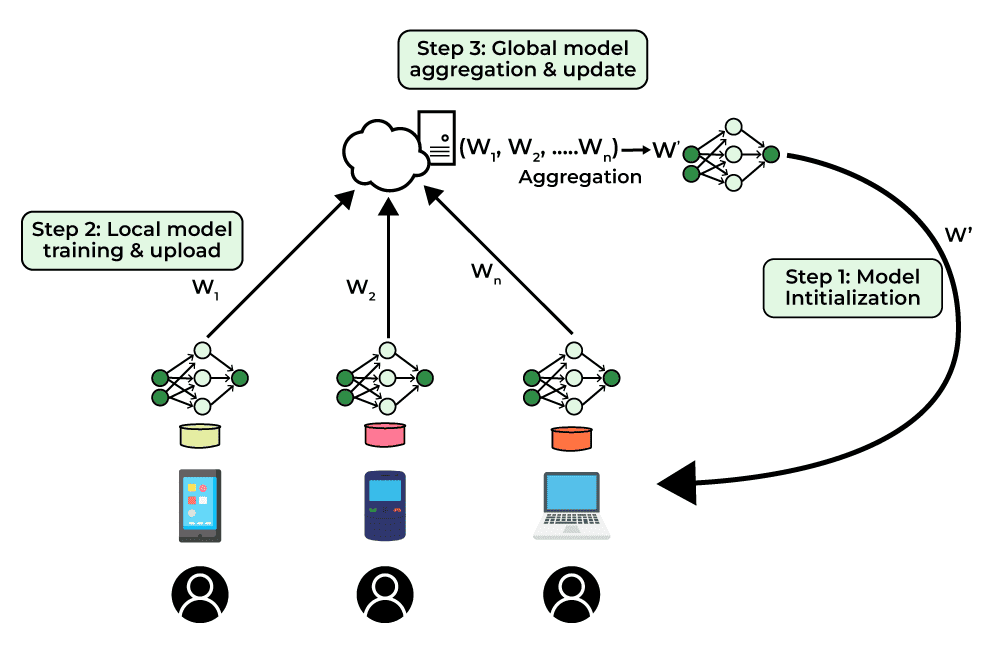


### 2. Why inspect data readiness before training?

In federated learning the server **never sees the client data**, so a silent data problem on one client (severe class imbalance, duplicated samples, corrupted/noisy images, outliers) shows up only as a mysteriously bad global model. *AI data readiness inspection* solves this by having each client compute quantitative readiness metrics **locally** and report only those aggregate numbers and plots to the server — the raw data never leaves the client.

APPFL's data readiness support follows the [AI Data Readiness Inspector (AIDRIN)](https://dl.acm.org/doi/pdf/10.1145/3676288.3676296) methodology:

> K. Hiniduma, S. Byna, J. L. Bez, and R. Madduri. *"AI Data Readiness Inspector (AIDRIN) for Quantitative Assessment of Data Readiness for AI"*, SSDBM 2024.

It gives you two complementary things:

#### (a) Standard readiness metrics — `data_readiness_configs.dr_metrics`

A catalogue of ready-to-use metrics and plots that you switch on/off with a boolean in the server configuration file, for example:

| Metric | What it tells you |
| --- | --- |
| `class_imbalance` | How far the label distribution is from uniform (0 = perfectly balanced) |
| `sample_size` / `num_classes` | How much data and how many labels the client holds |
| `completeness` | Fraction of non-missing (non-`NaN`) values |
| `sparsity` | Fraction of exactly-zero values |
| `variance`, `skewness`, `kurtosis`, `entropy` | Distributional shape of the raw features |
| `outlier_proportion` | Fraction of samples flagged as outliers |
| `brisque`, `sharpness`, `total_variation` | No-reference image quality scores |
| `plot.*` | Class-distribution pie chart, sample grid, pixel-value density, class-wise variance, ... |

#### (b) CADRE modules — `dr_metrics.cadremodule_configs`

**CADRE** (**C**ustomizable **A**ssurance of **D**ata **RE**adiness) modules let you go beyond reporting and actually *fix* a problem. A CADRE module subclasses `appfl.misc.data_readiness.BaseCADREModule` and implements three methods:

- `metric()` — compute a custom, domain-specific readiness number for the local dataset.
- `rule(metric_result)` — decide whether that number is bad enough to act on.
- `remedy(metric_result, logger)` — return an "AI-ready" version of the dataset (undersample the majority class, drop duplicates, filter outliers, ...).

APPFL ships five example CADRE modules for MNIST in `./resources/configs/mnist_dr/cadre_module/`:

| File | Class | Issue handled |
| --- | --- | --- |
| `handle_ci.py` | `CADREModuleCI` | Class imbalance (undersamples the majority class) |
| `handle_duplicates.py` | `CADREModuleDuplicates` | Duplicate samples |
| `handle_noise.py` | `CADREModuleNoise` | Noisy samples |
| `handle_outliers.py` | `CADREModuleOutliers` | Outliers (IQR on per-image mean/std) |
| `handle_mem.py` | `CADREModuleMem` | Excessive memory footprint |

Setting `remedy_action: true` tells the client to run `remedy()` and train on the repaired dataset; with `remedy_action: false` the module only reports.

#### What this tutorial does

This tutorial uses the **binary** version of MNIST (digits `0-4` → class `0`, digits `5-9` → class `1`) partitioned across two clients with a `class_noniid` strategy, so each client ends up with a **different and deliberately imbalanced** class ratio. We use `CADREModuleCI` with `remedy_action: true`, so each client will:

1. Measure its own readiness metrics,
2. Detect the class imbalance and rebalance its local dataset,
3. Send the resulting report to the server, which merges the two clients' reports into a single HTML file,
4. Train the global model on the repaired (AI-ready) data.


In [1]:
# [WARNING]: Please only run this cell ONCE at the beginning of your script.
# First: Change the working directory to the root of the examples folder and ignore warnings
import os
import warnings

os.chdir("../..")
warnings.filterwarnings("ignore")
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/zilinghan/Documents/projects/appfl/appfl-release/examples


In [2]:
# Set seed for reproducibility
import torch
import random
import numpy as np

seed_value = 1

random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
torch.cuda.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### 3. Create the federated learning server agent from configurations

Here we load and print the configurations needed to create a federated learning server. It is composed of two main parts: `client_configs` and `server_configs`.

The `client_configs` mainly contains **general** configurations that should be the same among all clients (e.g., training configurations, model architectures, and — for this tutorial — the data readiness configurations). Those configurations are shared with all the clients at the beginning of the experiment, which avoids having each client set the same configurations separately. In this example, `client_configs` has three main components:

- `client_configs.train_configs`: All training-related configurations:

    - *Trainer configurations*: The required trainer configurations depend on the trainer you use. You can also define your own trainer with any additional configurations you need, and then provide those configurations under `client_configs.train_configs` in the server configuration YAML file.

        - `trainer`: The class name of the trainer used for client local training, defined in `src/appfl/algorithm/trainer`. For example, `VanillaTrainer` simply updates the model for a certain number of epochs or batches.
        - `mode`: For `VanillaTrainer`, allowable values are `epoch` or `step`, specifying whether to train for a number of epochs or only a number of steps/batches.
        - `num_local_steps`/`num_local_epochs`: Number of steps (if `mode=step`) or epochs (if `mode=epoch`) for a client in each local training round.
        - `optim`, `optim_args`: Name of the optimizer from `torch.optim` and its keyword arguments.
        - `do_validation`, `do_pre_validation`: Whether to validate after / before each local training round.
        - `use_dp`, `epsilon`, `clip_grad`, `clip_value`, `clip_norm`: Differential privacy settings.
    - *Loss function*: either a `torch.nn` loss via `loss_fn`/`loss_fn_kwargs`, or your own via `loss_fn_path`/`loss_fn_name`.
    - *Metric function*: `metric_path` and `metric_name` point to the validation metric.
    - *Dataloader settings*: batch sizes and shuffling.
- `client_configs.model_configs`: The `torch.nn.Module` model definition, given as `model_path`, `model_name` and `model_kwargs`.
- `client_configs.data_readiness_configs`: The readiness metrics and plots each client should compute, and which CADRE module (if any) to apply. We look at it closely in the next cell.

The `server_configs` contains configurations specific to the federated learning server, such as the number of global epochs (total communication rounds between server and clients), the scheduler, and the aggregator.


In [3]:
from omegaconf import OmegaConf
from appfl.agent import ServerAgent

server_agent_config = OmegaConf.load(
    "./resources/configs/mnist_dr/server_fedavg_cadremodule.yaml"
)

print("==========Server Configuration==========")
print(OmegaConf.to_yaml(server_agent_config))
print("========================================")

W0824 10:58:31.100000 65302 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


==========Server Configuration==========
client_configs:
  train_configs:
    trainer: VanillaTrainer
    mode: step
    num_local_steps: 100
    optim: Adam
    optim_args:
      lr: 0.001
    loss_fn_path: ./resources/loss/celoss.py
    loss_fn_name: CELoss
    do_validation: true
    do_pre_validation: true
    metric_path: ./resources/metric/acc.py
    metric_name: accuracy
    use_dp: false
    epsilon: 1
    clip_grad: false
    clip_value: 1
    clip_norm: 1
    train_batch_size: 64
    val_batch_size: 64
    train_data_shuffle: true
    val_data_shuffle: false
  data_readiness_configs:
    generate_dr_report: true
    output_dirname: ./output
    output_filename: data_readiness_report
    dr_metrics:
      class_imbalance: false
      sample_size: true
      num_classes: false
      data_shape: false
      completeness: false
      data_range: false
      sparsity: false
      variance: false
      skewness: false
      entropy: false
      kurtosis: false
      class_distribut

#### 3.1 Turning readiness metrics on and off

The `data_readiness_configs` block controls everything about the inspection step:

```yaml
data_readiness_configs:
  generate_dr_report: True          # master switch
  output_dirname: "./output"        # where the merged HTML report is written
  output_filename: "data_readiness_report"
  dr_metrics:
    class_imbalance: False          # one boolean per standard metric
    sample_size: True
    ...
    plot:                           # one boolean per plot
      class_distribution_plot: true
      ...
    combine:                        # metrics merged across all clients
      feature_space_distribution: False
    cadremodule_configs:
      cadremodule_path: ./resources/configs/mnist_dr/cadre_module/handle_ci.py
      cadremodule_name: CADREModuleCI   # optional: last class in the file is used if omitted
      remedy_action: true               # true = actually repair the local dataset
```

The YAML file on disk is also used by other MPI/gRPC script examples, so instead of editing it we override a few settings **in memory** below to make the report in this tutorial richer. This is also a handy pattern for your own experiments.

Feel free to flip any of these booleans, or point `cadremodule_path`/`cadremodule_name` at one of the other modules (`handle_duplicates.py` → `CADREModuleDuplicates`, `handle_noise.py` → `CADREModuleNoise`, `handle_outliers.py` → `CADREModuleOutliers`, `handle_mem.py` → `CADREModuleMem`) to see a different issue being handled.

> **Note**: some entries (e.g. `combine.feature_space_distribution`) ship the full PCA projection of every sample to the server, so the readiness report can grow large. If a client fails with a *message larger than max size* gRPC error, raise `max_message_size` in **both** the server and the client gRPC configs — it is `10485760` (10 MB) in this tutorial. Increase the limit rather than dropping the metric you wanted.

In [4]:
dr_configs = server_agent_config.client_configs.data_readiness_configs

# Master switch: ask every client to produce a data readiness report
dr_configs.generate_dr_report = True

# Write the merged HTML report next to this notebook. The path is relative to
# `examples/`, which is the working directory set by the first cell.
dr_configs.output_dirname = "./notebook_tutorials/mnist_aidrin_nersc/output"

# Standard readiness metrics computed locally by every client
dr_configs.dr_metrics.class_imbalance = True
dr_configs.dr_metrics.sample_size = True
dr_configs.dr_metrics.num_classes = True
dr_configs.dr_metrics.completeness = True
dr_configs.dr_metrics.sparsity = True
dr_configs.dr_metrics.variance = True
dr_configs.dr_metrics.class_distribution = True

# Plots embedded (as base64 PNGs) in the merged HTML report
dr_configs.dr_metrics.plot.class_distribution_plot = True
dr_configs.dr_metrics.plot.data_sample_plot = True
dr_configs.dr_metrics.plot.class_variance_plot = True

# CADRE module: detect class imbalance and rebalance the local dataset
dr_configs.dr_metrics.cadremodule_configs.cadremodule_path = (
    "./resources/configs/mnist_dr/cadre_module/handle_ci.py"
)
dr_configs.dr_metrics.cadremodule_configs.cadremodule_name = "CADREModuleCI"
dr_configs.dr_metrics.cadremodule_configs.remedy_action = True

print("=======Data Readiness Configuration=======")
print(OmegaConf.to_yaml(dr_configs))
print("==========================================")

=======Data Readiness Configuration=======
generate_dr_report: true
output_dirname: ./notebook_tutorials/mnist_aidrin_nersc/output
output_filename: data_readiness_report
dr_metrics:
  class_imbalance: true
  sample_size: true
  num_classes: true
  data_shape: false
  completeness: true
  data_range: false
  sparsity: true
  variance: true
  skewness: false
  entropy: false
  kurtosis: false
  class_distribution: true
  brisque: false
  sharpness: false
  total_variation: false
  outlier_propotion: false
  plot:
    class_distribution_plot: true
    data_sample_plot: true
    data_distribution_plot: false
    class_variance_plot: true
  combine:
    feature_space_distribution: false
  cadremodule_configs:
    cadremodule_path: ./resources/configs/mnist_dr/cadre_module/handle_ci.py
    cadremodule_name: CADREModuleCI
    remedy_action: true



#### 3.2 The CADRE module

Below is the content of the selected CADRE module. Note the three methods required by `BaseCADREModule`:

- `metric()` returns `{"class_imbalance": <value>}` — a normalized Euclidean distance between the actual and the perfectly balanced class proportions, so `0.0` means perfectly balanced.
- `rule()` returns `True` when the imbalance exceeds a threshold (default `0`, i.e. any imbalance at all).
- `remedy()` undersamples the majority class down to the size of the minority class and returns the rebalanced dataset.

To write your own module for your own data issue, copy this structure, save it to a file, and point `cadremodule_path`/`cadremodule_name` at it.


In [5]:
cadremodule_file = server_agent_config.client_configs.data_readiness_configs.dr_metrics.cadremodule_configs.cadremodule_path
print(f"============CADRE Module: {cadremodule_file}============")
with open(cadremodule_file, "r") as f:
    print(f.read())
print("==============================================")

============CADRE Module: ./resources/configs/mnist_dr/cadre_module/handle_ci.py============
import torch
import random
import numpy as np
from appfl.misc.data_readiness import BaseCADREModule


class CADREModuleCI(BaseCADREModule):
    """
    CADREModuleCI specializing in noise detection with configurable parameters.
    This agent provides methods to compute class imbalance metrics, apply rules,
    and remedy imbalances in binary classification datasets.
    """

    def __init__(self, train_dataset, **kwargs):
        """
        Initialize the CADREModuleCI.

        Args:
        - train_dataset: The training dataset.
        - kwargs: Additional arguments for the base class.
        """
        super().__init__(train_dataset, **kwargs)

    def metric(self, **kwargs):
        """
        Compute the class imbalance metric for the dataset.

        Returns:
        - A dictionary containing the class imbalance metric.
        """
        # Retrieve labels from the dataset
      

#### 3.3 The model

Below is the content of the loaded model file, which defines a simple CNN for image classification on MNIST (images of size 1x28x28). Because this example turns MNIST into a **binary** problem (digits `0-4` vs. `5-9`), `model_kwargs.num_classes` is `2`.

If you would like to use your own model, define it in a similar way and provide its path as `model_path`, its class name as `model_name`, and any keyword arguments needed for initialization as `model_kwargs` in the server configuration YAML file. The model must be a class inherited from `torch.nn.Module`.


In [6]:
print("=============Model File Content===============")
model_file = server_agent_config.client_configs.model_configs.model_path
with open(model_file, "r") as f:
    print(f.read())
print("==============================================")

=============Model File Content===============
import math
import torch
import torch.nn as nn


class CNN(nn.Module):
    def __init__(self, num_channel, num_classes, num_pixel):
        super().__init__()
        self.conv1 = nn.Conv2d(
            num_channel, 32, kernel_size=5, padding=0, stride=1, bias=True
        )
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=0, stride=1, bias=True)
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2))
        self.act = nn.ReLU(inplace=False)

        ###
        ### X_out = floor{ 1 + (X_in + 2*padding - dilation*(kernel_size-1) - 1)/stride }
        ###
        X = num_pixel
        X = math.floor(1 + (X + 2 * 0 - 1 * (5 - 1) - 1) / 1)
        X = X / 2
        X = math.floor(1 + (X + 2 * 0 - 1 * (5 - 1) - 1) / 1)
        X = X / 2
        X = int(X)

        self.fc1 = nn.Linear(64 * X * X, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.max

In [7]:
# Create the server agent
server_agent = ServerAgent(server_agent_config=server_agent_config)

appfl: ✅[2026-08-24 10:58:36,335 server]: Logging to ./output/result_Server_2026-08-24-10-58-36.txt


### 4. gRPC server communicator creation

In this step, we create a server communicator that facilitates communication between the server and its clients using gRPC. It provides a reliable medium for the server and clients to exchange information efficiently and asynchronously.

**The following code block will print out an address that you need to copy into your two client notebooks.**


In [ ]:
from appfl.comm.grpc import GRPCServerCommunicator

server_agent_config.server_configs.comm_configs.grpc_configs.server_uri = (
    "0.0.0.0:50051"
)

# Start the gRPC server communicator
communicator = GRPCServerCommunicator(
    server_agent,
    logger=server_agent.logger,
    **server_agent_config.server_configs.comm_configs.grpc_configs,
)
print("✅ Replace server_uri with the one you got from the web interface")

### 5. Launch the server

Finally, we use the communicator to start serving the FL server, which handles the requests from the two clients.

Two things happen while this cell is running:

1. **Data readiness collection.** Each client sends a `get_data_readiness_report` custom action containing its locally computed metrics and plots. The server buffers them and, once **all** clients (`server_configs.num_clients`, here `2`) have reported, merges them into a single HTML file under `./output/`. You will see a `Data readiness report saved as HTML: ...` line in the log.
2. **Federated training.** The client training results are then logged in real time as a dictionary containing metrics such as `pre_val_accuracy` and `pre_val_loss` (accuracy and loss before each client's local training round) and `val_accuracy` and `val_loss` (accuracy and loss afterward). You should observe the model accuracy increasing as training proceeds.

> **Run the two client notebooks now.** This cell blocks until both clients have finished all `num_global_epochs` rounds and closed their connections.


In [9]:
from appfl.comm.grpc import serve

serve(
    communicator,
    **server_agent_config.server_configs.comm_configs.grpc_configs,
)

appfl: ✅[2026-08-24 10:58:44,073 server]: Received [1/2] GetConfiguration request from client Client1
appfl: ✅[2026-08-24 10:58:45,024 server]: Received InvokeCustomAction set_sample_size request from client Client1
appfl: ✅[2026-08-24 10:58:45,047 server]: Received InvokeCustomAction get_data_readiness_report request from client Client1
appfl: ✅[2026-08-24 10:58:46,687 server]: Received [2/2] GetConfiguration request from client Client2
appfl: ✅[2026-08-24 10:58:47,577 server]: Received InvokeCustomAction set_sample_size request from client Client2
appfl: ✅[2026-08-24 10:58:47,599 server]: Received InvokeCustomAction get_data_readiness_report request from client Client2
appfl: ✅[2026-08-24 10:58:47,627 server]: Data readiness report saved as HTML: ./notebook_tutorials/mnist_aidrin_nersc/output/data_readiness_report.html
appfl: ✅[2026-08-24 10:58:47,646 server]: Received GetGlobalModel request from client Client1
appfl: ✅[2026-08-24 10:58:47,646 server]: Received GetGlobalModel request

### 6. Inspect the merged data readiness report

The server writes the merged report to `<output_dirname>/<output_filename>.html` (appending `_1`, `_2`, ... if a report with that name already exists, so previous runs are never overwritten).

The report contains one table row per client with all the enabled scalar metrics, followed by the per-client plots. Run the cell below to render the most recent report inline. You can also open the `.html` file directly from the JupyterLab file browser.


Showing: /Users/zilinghan/Documents/projects/appfl/appfl-release/examples/notebook_tutorials/mnist_aidrin_nersc/output/data_readiness_report.html



Class Distribution,Class Imbalance,Completeness,Num Classes,Sample Size,Specified Metrics,Variance
"{0: 12515, 1: 12515}",0.0,1.0,2,25030,{'class_imbalance': 0.0},0.1
"{0: 13058, 1: 13058}",0.0,1.0,2,26116,{'class_imbalance': 0.0},0.09

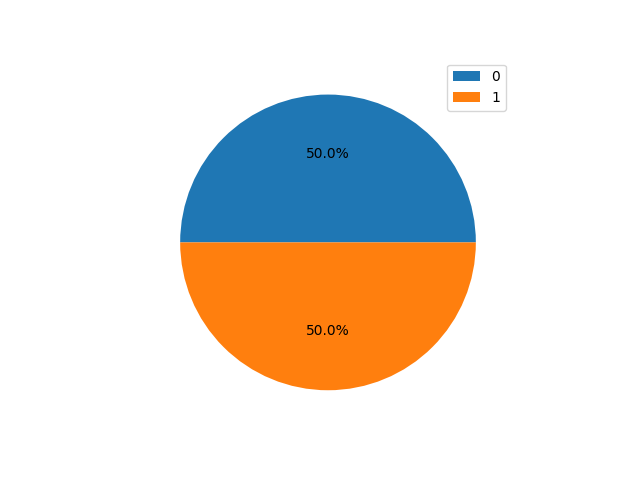
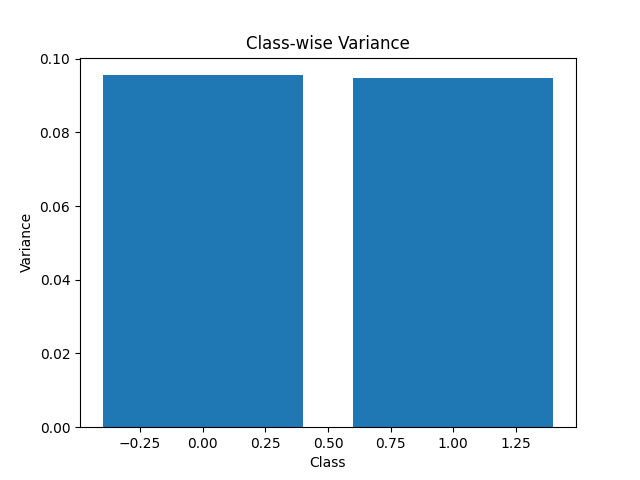
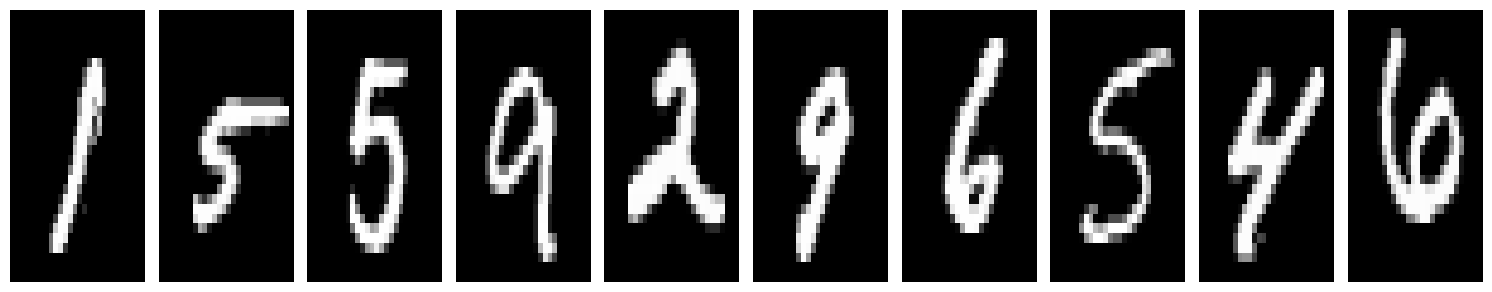
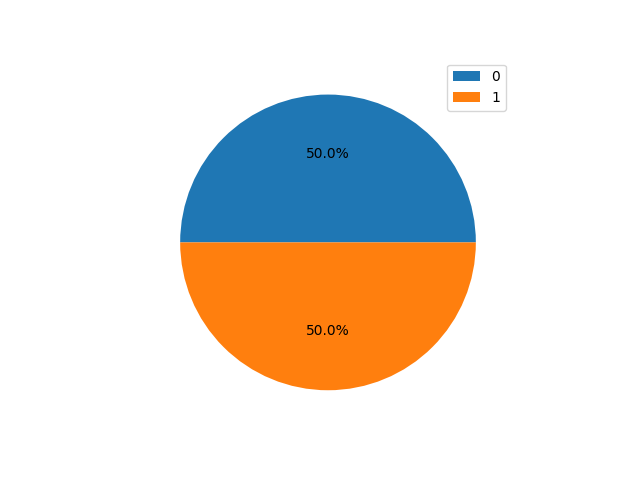
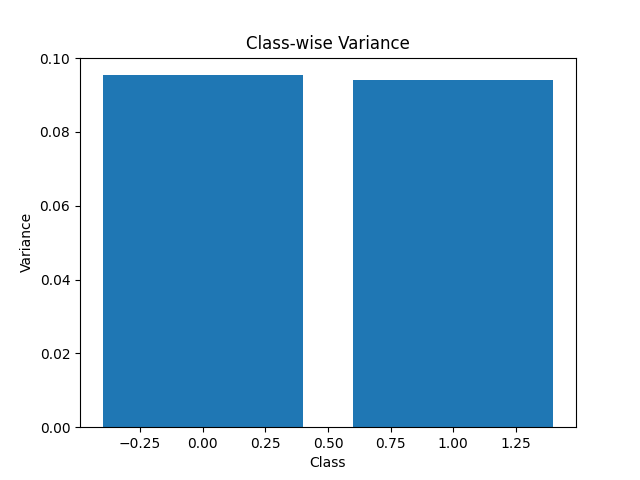
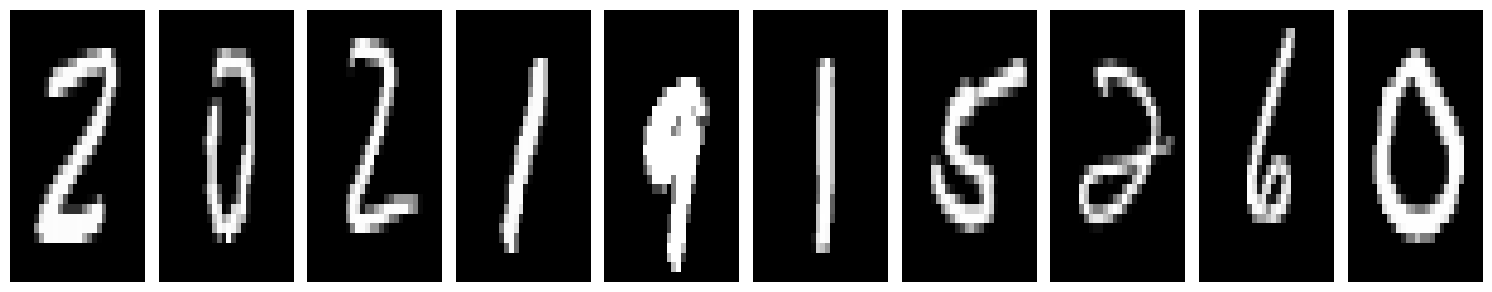

In [10]:
import glob
from IPython.display import HTML, display

dr_configs = server_agent_config.client_configs.data_readiness_configs
output_dir = dr_configs.get("output_dirname", "./output")
output_filename = dr_configs.get("output_filename", "data_readiness_report")

reports = sorted(
    glob.glob(os.path.join(output_dir, f"{output_filename}*.html")),
    key=os.path.getmtime,
)
if not reports:
    print(f"No data readiness report found in {os.path.abspath(output_dir)}.")
else:
    latest_report = reports[-1]
    print(f"Showing: {os.path.abspath(latest_report)}\n")
    with open(latest_report, "r") as f:
        display(HTML(f.read()))

### 7. Where to go next

- **Try another data issue.** Point `cadremodule_configs` at `handle_duplicates.py`, `handle_noise.py`, `handle_outliers.py`, or `handle_mem.py` (and restart all three notebooks). The dataset loader `./resources/dataset/mnist_dataset_dr.py` also contains helpers (`add_noise_to_subset`, `add_duplicates` from `appfl.misc.data_readiness.data_pollute`) for deliberately injecting issues into the otherwise very clean MNIST data.
- **Report only, do not repair.** Set `remedy_action: false` to compare the "before" numbers against a run with the remedy enabled.
- **Write your own CADRE module.** Subclass `appfl.misc.data_readiness.BaseCADREModule`, implement `metric`, `rule` and `remedy`, and point `cadremodule_path` at your file.
- **Run it as a script instead.** The same configuration works with MPI and gRPC launchers — see `./resources/configs/mnist_dr/README.md`.
